In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [5]:
# Load the dataset
df = pd.read_csv("final_alcohol.csv")

# Drop index columns that aren't useful for prediction
df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

# Convert 'Type' (White/Red Wine) into 0 and 1
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# Check the first few rows to ensure it's clean
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.17         0.29            1.40      0.047   
1            5.3              0.31         0.38           10.50      0.031   
2            6.9              0.26         0.29            4.20      0.043   
3            8.4              0.32         0.35           11.70      0.029   
4            7.4              0.30         0.22            5.25      0.053   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 23.0                 107.0  0.99390  3.52       0.65   
1                 53.0                 140.0  0.99321  3.34       0.46   
2                 33.0                 114.0  0.99020  3.16       0.31   
3                  3.0                  46.0  0.99439  3.02       0.34   
4                 33.0                 180.0  0.99260  3.13       0.45   

   alcohol  quality  Type  
0     10.4        6     1  
1     11.7        6     1  
2 

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Type
0,7.4,0.17,0.29,1.40,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,6,1
1,5.3,0.31,0.38,10.50,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,6,1
2,6.9,0.26,0.29,4.20,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,6,1
3,8.4,0.32,0.35,11.70,0.029,3.0,46.0,0.99439,3.02,0.34,11.8,6,1
4,7.4,0.30,0.22,5.25,0.053,33.0,180.0,0.99260,3.13,0.45,11.6,6,1


In [7]:
df['quality'].value_counts()

quality
6    2076
5    1304
7     868
8     159
4     118
3      11
9       5
Name: count, dtype: int64

In [8]:
df["quality"] = (df["quality"] >= 6).astype(int)

In [11]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Type
0,7.4,0.17,0.29,1.40,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,1,1
1,5.3,0.31,0.38,10.50,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,1,1
2,6.9,0.26,0.29,4.20,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,1,1
3,8.4,0.32,0.35,11.70,0.029,3.0,46.0,0.99439,3.02,0.34,11.8,1,1
4,7.4,0.30,0.22,5.25,0.053,33.0,180.0,0.99260,3.13,0.45,11.6,1,1


In [16]:
# Features (everything except quality)
X = df.drop('quality', axis=1)

# Target (the quality score)
y = df['quality']

In [17]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Type
0,7.4,0.17,0.29,1.40,0.047,23.0,107.0,0.99390,3.52,0.65,10.4,1
1,5.3,0.31,0.38,10.50,0.031,53.0,140.0,0.99321,3.34,0.46,11.7,1
2,6.9,0.26,0.29,4.20,0.043,33.0,114.0,0.99020,3.16,0.31,12.5,1
3,8.4,0.32,0.35,11.70,0.029,3.0,46.0,0.99439,3.02,0.34,11.8,1
4,7.4,0.30,0.22,5.25,0.053,33.0,180.0,0.99260,3.13,0.45,11.6,1


In [18]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: quality, dtype: int64

In [23]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
enc

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


# fit and tranform the column

In [27]:
enc.fit(X_train[['Type']])

X_train_encoded = enc.transform(X_train[['Type']])
X_test_encoded = enc.transform(X_test[['Type']])

# convert the arrays to df

In [28]:
encoded_cols = enc.get_feature_names_out(['Type'])

X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

# Drop og rows and replace with encoded row

In [29]:
X_train_final = pd.concat([X_train.drop(columns=['Type']), X_train_encoded], axis=1)
X_test_final = pd.concat([X_test.drop(columns=['Type']), X_test_encoded], axis=1)

In [31]:
# Initialize the model with 100 trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate the Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Show detailed report (Precision, Recall, etc.)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 83.06%

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.66      0.70       272
           1       0.86      0.90      0.88       637

    accuracy                           0.83       909
   macro avg       0.80      0.78      0.79       909
weighted avg       0.83      0.83      0.83       909



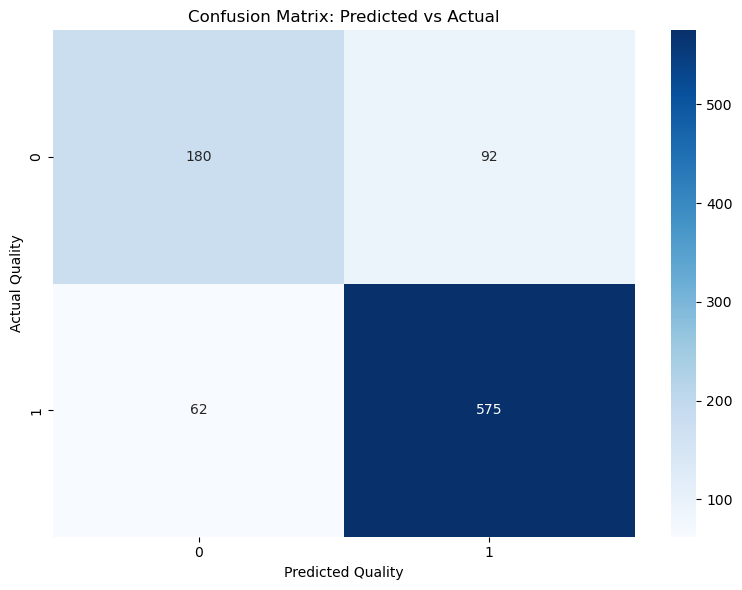

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt  # Added .pyplot here
from sklearn.metrics import confusion_matrix
import pandas as pd

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting with Seaborn
plt.figure(figsize=(8, 6))

# Note: Ensure 'y' is defined, or use y_test for labels
labels = sorted(pd.Series(y_test).unique())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show() # Added this to display the plot in your notebook/IDE

C:\Users\HP\AppData\Local\Temp\ipykernel_4760\179247470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


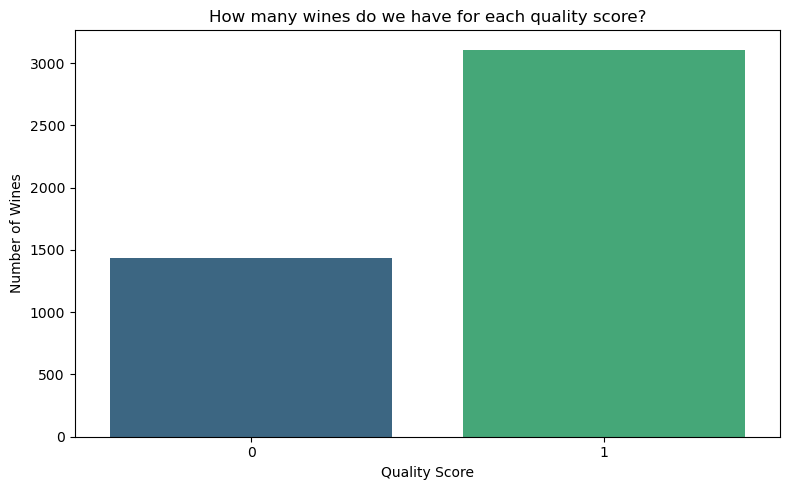

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('How many wines do we have for each quality score?')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')
plt.tight_layout()
plt.savefig('quality_distribution.png')